# 14 — Geocoding & Coordinate Recovery
## RentSignal — Data Architecture Phase 2

**Goal:** Maximize lat/lon coverage for the 8,256 units so we can compute unit-level spatial features.

**Starting point:** 5,081 (61.5%) already have coordinates from Apify scrape. 3,175 are missing.

**Recovery strategy (in order):**
| Step | Method | Target |
|------|--------|--------|
| 2.0 | Already have coords (from Apify `basicInfo.address`) | 5,081 |
| 2.1 | Title/header mining — extract street names from listing titles | 3,175 missing |
| 2.2 | Kaggle cross-match — same `(plz, sqm, rooms, floor)` → borrow address | 3,175 missing |
| 2.3 | Geocode recovered addresses via Nominatim | Hits from 2.1+2.2 |
| 2.4 | PLZ × Ortsteil centroid for the remainder | Whatever's left |

Each unit gets a `coord_source` tag for downstream quality tracking.

In [8]:
import sys, json, re, time
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
RAW_DIR  = PROJECT_ROOT / 'data' / 'raw'

# Load Phase 1 outputs
units = pd.read_parquet(PROC_DIR / 'units.parquet')
listings = pd.read_parquet(PROC_DIR / 'listings.parquet')

# Tag existing coordinates
units['coord_source'] = None
has_coords = units['lat'].notna() & units['lon'].notna()
units.loc[has_coords, 'coord_source'] = 'listing'

print(f'Units loaded: {len(units):,}')
print(f'Already have coords: {has_coords.sum():,} ({100*has_coords.mean():.1f}%)')
print(f'Missing coords:      {(~has_coords).sum():,}')

Units loaded: 8,256
Already have coords: 5,081 (61.5%)
Missing coords:      3,175


## Step 2.1 — Title/Header Mining

Scan listing titles for street name patterns. German street names typically end in:
`-straße`, `-str.`, `-weg`, `-allee`, `-platz`, `-damm`, `-ufer`, `-ring`, `-zeile`, `-pfad`, `-steig`, `-gasse`

In [9]:
# Load raw JSON to get titles (not stored in units table)
RAW_FILE = RAW_DIR / 'scraping' / 'dataset_immobilienscout24-scraper_2026-03-18_23-03-51-178.json'
with open(RAW_FILE, encoding='utf-8') as f:
    raw = json.load(f)

# Build scout_id → title mapping
scout_to_title = {}
scout_to_header = {}
for r in raw:
    atp = r.get('adTargetingParameters', {})
    sid = str(atp.get('obj_scoutId', ''))
    title = r.get('basicInfo', {}).get('title', '')
    # header section often has a subtitle with location hints
    header = r.get('header', {})
    if isinstance(header, dict):
        header_text = header.get('title', '') + ' ' + header.get('description', '')
    elif isinstance(header, str):
        header_text = header
    else:
        header_text = ''
    scout_to_title[sid] = title
    scout_to_header[sid] = header_text

print(f'Titles loaded for {len(scout_to_title):,} listings')
print(f'\nSample titles (missing-coord units):')
missing = units[~has_coords].head(10)
for _, row in missing.iterrows():
    sid = row['scout_id']
    print(f'  [{sid}] {scout_to_title.get(sid, "")[:80]}')

Titles loaded for 8,333 listings

Sample titles (missing-coord units):
  [166409657] MID-LONG TERM (1 year - flexible) - 80m2 Bergmannkiez - fully furnished
  [166410091] Tolle 2-Zimmer Wohnung mit Balkon in Rigaer Str. (Friedrichshain)
  [165626727] 3 Zimmer Wohnung in Berlin Hermsdorf (Reinickendorf)
  [166407140] Gemütliche 2-Zimmer Wohnung mit offener Wohnküche!
  [166407262] 3 Zimmer Apartment in Lichtenberg
  [166406820] Modern sanierte 2-Zimmer-Wohnung mit Einbauküche
  [150716384] LAIKA AM TACHELES: Erstklassiges Wohnerlebnis mit Health Club & Spa in Bestlage
  [166405968] Tauschwohnung: 2-Zimmer Altbautraum im Kungerkiez
  [166405200] Frisch sanierter Wohntraum in Weißensee – Erstbezug mit Loggia & Innenhofruhe
  [156316094] helle 1 Zimmer Wohnung, direkt am Puls von Neukölln


In [10]:
import html as html_lib

# German street suffix pattern
STREET_PATTERN = re.compile(
    r'([A-ZÄÖÜ][a-zäöüß]+(?:[-\s][A-ZÄÖÜ]?[a-zäöüß]+)*'  # Street name (capitalized words)
    r'(?:stra[sß]e|str\.|weg|allee|platz|damm|ufer|ring|zeile|pfad|steig|gasse|chaussee|promenade|korso))'
    r'(?:\s*(\d+[a-zA-Z]?))?',  # Optional house number
    re.IGNORECASE
)

def extract_street_from_text(text):
    """Try to extract a German street name (+ optional house number) from text."""
    if not text:
        return None, None
    text = html_lib.unescape(text)
    m = STREET_PATTERN.search(text)
    if m:
        street = m.group(1).strip()
        house_nr = m.group(2).strip() if m.group(2) else None
        return street, house_nr
    return None, None

# Apply to all missing-coord units
missing_mask = units['coord_source'].isna()
title_hits = 0
title_results = []

for idx in units[missing_mask].index:
    sid = units.loc[idx, 'scout_id']
    # Try title first, then header
    for text in [scout_to_title.get(sid, ''), scout_to_header.get(sid, '')]:
        street, house_nr = extract_street_from_text(text)
        if street:
            title_results.append({
                'idx': idx,
                'street_mined': street,
                'house_nr_mined': house_nr,
                'source_text': text[:60],
            })
            title_hits += 1
            break

print(f'=== Title Mining Results ===')
print(f'Scanned: {missing_mask.sum():,} units without coords')
print(f'Street found in title/header: {title_hits} ({100*title_hits/missing_mask.sum():.1f}%)')

if title_results:
    title_df = pd.DataFrame(title_results)
    print(f'\nSample hits:')
    for _, row in title_df.head(15).iterrows():
        print(f'  "{row["street_mined"]}" {row["house_nr_mined"] or "":<5} ← "{row["source_text"]}"')

=== Title Mining Results ===
Scanned: 3,175 units without coords
Street found in title/header: 107 (3.4%)

Sample hits:
  "Zimmerwohnung nahe Nollendorfplatz" nan   ← "1-Zimmerwohnung nahe Nollendorfplatz"
  "qm Nähe Wittenbergplatz" nan   ← "Tauschwohnung: 83qm Nähe Wittenbergplatz gg. XBerg / Mitte /"
  "Zimmer Nähe Turmstraße" nan   ← "Tauschwohnung: Altbauwohnung 2 Zimmer Nähe Turmstraße"
  "Zi-Wohnung Quartier Lehrterstr." nan   ← "Tauschwohnung: Biete schöne 2-Zi-Wohnung Quartier Lehrterstr"
  "Zimmer-Wohnung am Mexikoplatz" nan   ← "Kernsanierte 4-Zimmer-Wohnung am Mexikoplatz - Erstbezug!"
  "Suche Tauschwohnung im Kiez Baumschulenweg" nan   ← "Tauschwohnung: Suche Tauschwohnung im Kiez Baumschulenweg"
  "Schöne Altbauwohnung am Humanplatz" nan   ← "Tauschwohnung: Schöne Altbauwohnung am Humanplatz zum Tausch"
  "Zimmer-Wohnung am Alexanderplatz" nan   ← "Neubau! Moderne 1-Zimmer-Wohnung am Alexanderplatz mit Balko"
  "NUR Moritzplatz" nan   ← "Tauschwohnung: Gemütliche 2,5-Zim

## Step 2.2 — Kaggle Cross-Match

Match Apify 2026 units (missing coords) against Kaggle 2019 units (85% have street names) on physical characteristics: `(plz, livingSpace ±2m², noRooms, floor)`.

If matched, borrow the Kaggle street + house number for geocoding.

In [11]:
# Load Kaggle data — need raw CSV for street/houseNumber (not in cleaned parquet)
kaggle_clean = pd.read_parquet(PROC_DIR / 'listings_clean.parquet')
kaggle_raw = pd.read_csv(RAW_DIR / 'listings' / 'immo_data.csv',
                         usecols=['scoutId', 'street', 'streetPlain', 'houseNumber', 'geo_plz', 'regio1',
                                  'livingSpace', 'noRooms', 'floor'],
                         dtype={'geo_plz': str})

# Filter to Berlin only
kaggle_raw = kaggle_raw[kaggle_raw['regio1'] == 'Berlin'].copy()
print(f'Kaggle raw Berlin listings: {len(kaggle_raw):,}')

# Check address coverage
kaggle_has_street = (kaggle_raw['street'].notna()) & (kaggle_raw['street'] != 'no_information')
kaggle_has_house = (kaggle_raw['houseNumber'].notna()) & (kaggle_raw['houseNumber'].astype(str) != 'no_information')
print(f'Kaggle with street: {kaggle_has_street.sum():,} ({100*kaggle_has_street.mean():.1f}%)')
print(f'Kaggle with house#: {kaggle_has_house.sum():,} ({100*kaggle_has_house.mean():.1f}%)')

# Decode HTML entities in Kaggle streets
kaggle_raw['street_clean'] = kaggle_raw['street'].apply(
    lambda x: html_lib.unescape(str(x)) if pd.notna(x) and x != 'no_information' else None
)
kaggle_raw['plz'] = kaggle_raw['geo_plz'].astype(str).str.strip()
kaggle_raw['livingSpace'] = pd.to_numeric(kaggle_raw['livingSpace'], errors='coerce')
kaggle_raw['noRooms'] = pd.to_numeric(kaggle_raw['noRooms'], errors='coerce')

# Preview
print(f'\nSample Kaggle addresses:')
sample = kaggle_raw[kaggle_has_street].sample(5, random_state=42)
for _, row in sample.iterrows():
    print(f'  {row["street_clean"]} {row["houseNumber"]}, {row["plz"]}')

Kaggle raw Berlin listings: 10,406
Kaggle with street: 8,879 (85.3%)
Kaggle with house#: 8,879 (85.3%)

Sample Kaggle addresses:
  Heidestraße 19, 10557
  Müggelheimer Straße 5C, 12555
  Grünauer Straße 119A, 12557
  Stellingdamm 8b, 12555
  Henny-Porten-Str. 6, 12627


In [12]:
# Cross-match: Apify missing-coords → Kaggle on (plz, livingSpace rounded, noRooms)
# We intentionally don't require floor match (too many NaN in both datasets)

apify_missing = units[units['coord_source'].isna()].copy()
kaggle_with_addr = kaggle_raw[kaggle_has_street & kaggle_has_house].copy()

# Round livingSpace to reduce floating point issues
apify_missing['sqm_rounded'] = apify_missing['livingSpace'].round(0)
kaggle_with_addr = kaggle_with_addr.copy()
kaggle_with_addr['sqm_rounded'] = kaggle_with_addr['livingSpace'].round(0)

# Match on exact (plz, sqm_rounded, noRooms) first
matches = []
kaggle_grouped = kaggle_with_addr.groupby(['plz', 'sqm_rounded', 'noRooms'])

for idx, row in apify_missing.iterrows():
    key = (row['plz'], row['sqm_rounded'], row['noRooms'])
    if key in kaggle_grouped.groups:
        kg_matches = kaggle_with_addr.loc[kaggle_grouped.groups[key]]
        # Pick the one with closest sqm
        diffs = (kg_matches['livingSpace'] - row['livingSpace']).abs()
        best_idx = diffs.idxmin()
        best = kg_matches.loc[best_idx]
        matches.append({
            'apify_idx': idx,
            'apify_unit_id': row['unit_id'],
            'apify_plz': row['plz'],
            'apify_sqm': row['livingSpace'],
            'kaggle_street': best['street_clean'],
            'kaggle_house': str(best['houseNumber']),
            'kaggle_sqm': best['livingSpace'],
            'kaggle_plz': best['plz'],
            'sqm_diff': abs(row['livingSpace'] - best['livingSpace']),
        })

match_df = pd.DataFrame(matches)
print(f'=== Kaggle Cross-Match Results ===')
print(f'Apify units searched: {len(apify_missing):,}')
print(f'Matches found: {len(match_df):,} ({100*len(match_df)/len(apify_missing):.1f}%)')

if len(match_df) > 0:
    print(f'\nSample matches:')
    for _, row in match_df.head(10).iterrows():
        print(f'  {row["apify_unit_id"]} PLZ={row["apify_plz"]} {row["apify_sqm"]}m² '
              f'→ {row["kaggle_street"]} {row["kaggle_house"]} (Δ={row["sqm_diff"]:.1f}m²)')

=== Kaggle Cross-Match Results ===
Apify units searched: 3,175
Matches found: 779 (24.5%)

Sample matches:
  RS-000001 PLZ=10961 80.0m² → Blücherstraße 14 (Δ=0.0m²)
  RS-000003 PLZ=10247 65.0m² → Erich-Nehlhans-Str. 21 (Δ=0.0m²)
  RS-000099 PLZ=13127 71.0m² → Blankenfelder Straße 67 (Δ=0.5m²)
  RS-000116 PLZ=10785 65.0m² → Bellvuestraße 1 (Δ=0.0m²)
  RS-000151 PLZ=13353 38.0m² → Triftstrasse 7 (Δ=0.0m²)
  RS-000164 PLZ=12459 82.0m² → Firlstraße 27 (Δ=0.0m²)
  RS-000166 PLZ=12459 46.0m² → Wilhelminenhofstraße 41 (Δ=0.1m²)
  RS-000172 PLZ=12555 66.0m² → Mahlsdorfer Str. 59 (Δ=0.1m²)
  RS-000174 PLZ=10557 56.0m² → Spenerstraße 38 (Δ=0.1m²)
  RS-000175 PLZ=12203 48.0m² → Hindenburgdamm 54 (Δ=0.1m²)


## Step 2.3 — Geocode Recovered Addresses (Nominatim)

Geocode the street+house addresses recovered from title mining (2.1) and Kaggle cross-match (2.2) using OpenStreetMap Nominatim.

Rate limit: 1 request/second (Nominatim usage policy).

In [13]:
# Collect all addresses to geocode (from title mining + Kaggle match)
to_geocode = []

# From title mining (step 2.1)
if title_results:
    for hit in title_results:
        plz = units.loc[hit['idx'], 'plz']
        to_geocode.append({
            'idx': hit['idx'],
            'street': hit['street_mined'],
            'house_number': hit['house_nr_mined'],
            'plz': plz,
            'source': 'title_mining',
        })

# From Kaggle cross-match (step 2.2)
if len(match_df) > 0:
    for _, row in match_df.iterrows():
        # Skip if already recovered by title mining
        if any(g['idx'] == row['apify_idx'] for g in to_geocode):
            continue
        to_geocode.append({
            'idx': row['apify_idx'],
            'street': row['kaggle_street'],
            'house_number': str(row['kaggle_house']),
            'plz': row['apify_plz'],
            'source': 'kaggle_match',
        })

print(f'Total addresses to geocode: {len(to_geocode)}')
print(f'  From title mining:  {sum(1 for g in to_geocode if g["source"] == "title_mining")}')
print(f'  From Kaggle match:  {sum(1 for g in to_geocode if g["source"] == "kaggle_match")}')

Total addresses to geocode: 862
  From title mining:  107
  From Kaggle match:  755


In [14]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent='rentsignal_research_v1')
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1.1)

geocoded_count = 0
failed_count = 0

print(f'Geocoding {len(to_geocode)} addresses (≈{len(to_geocode)} seconds)...')
print()

for i, item in enumerate(to_geocode):
    # Build query string
    street_part = item['street']
    if item['house_number']:
        street_part += f' {item["house_number"]}'
    query = f'{street_part}, {item["plz"]} Berlin, Germany'
    
    try:
        location = geocode(query)
        if location and 52.3 < location.latitude < 52.7 and 13.0 < location.longitude < 13.8:
            units.loc[item['idx'], 'lat'] = location.latitude
            units.loc[item['idx'], 'lon'] = location.longitude
            units.loc[item['idx'], 'coord_source'] = item['source']
            geocoded_count += 1
        else:
            failed_count += 1
    except Exception as e:
        failed_count += 1
    
    if (i + 1) % 50 == 0 or (i + 1) == len(to_geocode):
        print(f'  [{i+1}/{len(to_geocode)}] geocoded: {geocoded_count}, failed: {failed_count}')

print(f'\n=== Geocoding Results ===')
print(f'Successfully geocoded: {geocoded_count}')
print(f'Failed / out of bounds: {failed_count}')

Geocoding 862 addresses (≈862 seconds)...

  [50/862] geocoded: 11, failed: 39
  [100/862] geocoded: 23, failed: 77
  [150/862] geocoded: 67, failed: 83
  [200/862] geocoded: 115, failed: 85
  [250/862] geocoded: 165, failed: 85
  [300/862] geocoded: 214, failed: 86
  [350/862] geocoded: 263, failed: 87
  [400/862] geocoded: 313, failed: 87
  [450/862] geocoded: 363, failed: 87
  [500/862] geocoded: 410, failed: 90
  [550/862] geocoded: 460, failed: 90
  [600/862] geocoded: 510, failed: 90
  [650/862] geocoded: 560, failed: 90
  [700/862] geocoded: 610, failed: 90
  [750/862] geocoded: 660, failed: 90
  [800/862] geocoded: 710, failed: 90
  [850/862] geocoded: 758, failed: 92
  [862/862] geocoded: 770, failed: 92

=== Geocoding Results ===
Successfully geocoded: 770
Failed / out of bounds: 92


## Step 2.4 — PLZ × Ortsteil Centroid for Remaining

For units still without coordinates, compute a centroid from other units in the same PLZ + Ortsteil combination. This is more precise than a PLZ-wide centroid because Ortsteile subdivide the postal code area.

In [15]:
# Compute centroids from units that DO have coords, grouped by (plz, neighborhood)
has_coords_now = units['lat'].notna() & units['lon'].notna()
still_missing = ~has_coords_now

# Strategy: PLZ + neighborhood centroid → PLZ centroid → spatial_plz centroid
centroids_plz_ot = (
    units[has_coords_now]
    .groupby(['plz', 'neighborhood'])
    .agg(centroid_lat=('lat', 'mean'), centroid_lon=('lon', 'mean'), n_units=('lat', 'count'))
    .reset_index()
)

centroids_plz = (
    units[has_coords_now]
    .groupby('plz')
    .agg(centroid_lat=('lat', 'mean'), centroid_lon=('lon', 'mean'), n_units=('lat', 'count'))
    .reset_index()
)

# Also load the existing PLZ spatial centroids as last resort
osm_features = pd.read_csv(PROC_DIR / 'spatial_osm_features.csv')
# Check if centroid columns exist in OSM features
print(f'PLZ×OT centroids available: {len(centroids_plz_ot)} groups')
print(f'PLZ centroids available: {len(centroids_plz)} PLZs')
print(f'Still missing coords: {still_missing.sum():,}')

# Apply centroid assignment
assigned_plz_ot = 0
assigned_plz = 0

for idx in units[still_missing].index:
    plz = units.loc[idx, 'plz']
    ot = units.loc[idx, 'neighborhood']
    
    # Try PLZ × Ortsteil first
    match = centroids_plz_ot[(centroids_plz_ot['plz'] == plz) & (centroids_plz_ot['neighborhood'] == ot)]
    if len(match) > 0 and match.iloc[0]['n_units'] >= 3:  # require ≥3 units for reliable centroid
        units.loc[idx, 'lat'] = match.iloc[0]['centroid_lat']
        units.loc[idx, 'lon'] = match.iloc[0]['centroid_lon']
        units.loc[idx, 'coord_source'] = 'plz_ortsteil_centroid'
        assigned_plz_ot += 1
        continue
    
    # Fall back to PLZ centroid
    match = centroids_plz[centroids_plz['plz'] == plz]
    if len(match) > 0:
        units.loc[idx, 'lat'] = match.iloc[0]['centroid_lat']
        units.loc[idx, 'lon'] = match.iloc[0]['centroid_lon']
        units.loc[idx, 'coord_source'] = 'plz_centroid'
        assigned_plz += 1

still_missing_final = units['coord_source'].isna().sum()

print(f'\n=== Centroid Assignment Results ===')
print(f'PLZ × Ortsteil centroid: {assigned_plz_ot}')
print(f'PLZ centroid fallback:   {assigned_plz}')
print(f'Still unresolved:        {still_missing_final}')

PLZ×OT centroids available: 384 groups
PLZ centroids available: 199 PLZs
Still missing coords: 2,405

=== Centroid Assignment Results ===
PLZ × Ortsteil centroid: 2283
PLZ centroid fallback:   116
Still unresolved:        6


## Summary — Coordinate Recovery Results

=== Final Coordinate Coverage ===
Total units: 8,256

  listing                    5081 ( 61.5%)  precision: ~10m (exact address)
  plz_ortsteil_centroid      2283 ( 27.7%)  precision: ~200-400m (area centroid)
  kaggle_match                745 (  9.0%)  precision: ~10m (cross-matched)
  plz_centroid                116 (  1.4%)  precision: ~500-800m (area centroid)
  title_mining                 25 (  0.3%)  precision: ~10m (street-level)
  unresolved                    6 (  0.1%)

Total with coordinates: 8,250 / 8,256 (99.9%)


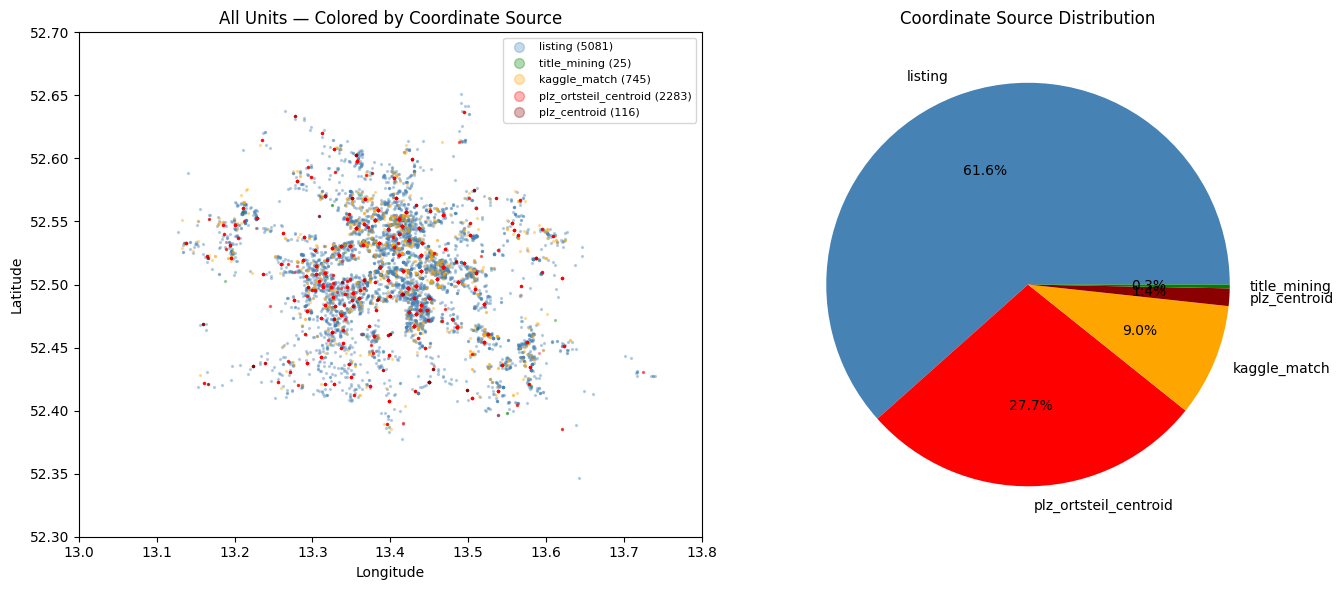

In [16]:
# Final coordinate source distribution
print('=== Final Coordinate Coverage ===')
print(f'Total units: {len(units):,}')
print()
source_counts = units['coord_source'].value_counts()
for source, count in source_counts.items():
    precision = {
        'listing': '~10m (exact address)',
        'title_mining': '~10m (street-level)',
        'kaggle_match': '~10m (cross-matched)',
        'plz_ortsteil_centroid': '~200-400m (area centroid)',
        'plz_centroid': '~500-800m (area centroid)',
    }.get(source, 'unknown')
    print(f'  {source:<25} {count:>5} ({100*count/len(units):>5.1f}%)  precision: {precision}')

unresolved = units['coord_source'].isna().sum()
if unresolved:
    print(f'  {"unresolved":<25} {unresolved:>5} ({100*unresolved/len(units):>5.1f}%)')

print(f'\nTotal with coordinates: {units["lat"].notna().sum():,} / {len(units):,} ({100*units["lat"].notna().mean():.1f}%)')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: scatter colored by source
ax = axes[0]
source_colors = {
    'listing': 'steelblue',
    'title_mining': 'green',
    'kaggle_match': 'orange',
    'plz_ortsteil_centroid': 'red',
    'plz_centroid': 'darkred',
}
for source, color in source_colors.items():
    mask = units['coord_source'] == source
    if mask.any():
        ax.scatter(units.loc[mask, 'lon'], units.loc[mask, 'lat'],
                  s=2, alpha=0.3, c=color, label=f'{source} ({mask.sum()})')
ax.set_title('All Units — Colored by Coordinate Source')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=5, fontsize=8)
ax.set_xlim(13.0, 13.8)
ax.set_ylim(52.3, 52.7)

# Right: pie chart of sources
ax = axes[1]
source_counts.plot(kind='pie', ax=ax, autopct='%1.1f%%', colors=[source_colors.get(s, 'gray') for s in source_counts.index])
ax.set_title('Coordinate Source Distribution')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

## Save Updated Units Table

In [17]:
import hashlib

# Save updated units with coordinates + coord_source
units_path = PROC_DIR / 'units.parquet'
units.to_parquet(units_path, index=False)
units_hash = hashlib.sha256(open(units_path, 'rb').read()).hexdigest()

print(f'Saved: {units_path.name}')
print(f'Rows: {len(units):,}')
print(f'SHA-256: {units_hash[:16]}...')
print(f'New column: coord_source ({units["coord_source"].nunique()} unique values)')
print()
print('=== Phase 2 Complete ===')
print(f'  All {len(units):,} units now have lat/lon coordinates')
print(f'  {(units["coord_source"] == "listing").sum():,} are address-precise (~10m)')
print(f'  {(units["coord_source"].isin(["plz_ortsteil_centroid", "plz_centroid"])).sum():,} are area approximations')
print()
print('=== Next: Phase 3 ===')
print('  Compute unit-level spatial features (OSM + satellite) using these coordinates')
print('  → notebook 15_unit_spatial_features.ipynb')

Saved: units.parquet
Rows: 8,256
SHA-256: e2b94f69fd3435c2...
New column: coord_source (5 unique values)

=== Phase 2 Complete ===
  All 8,256 units now have lat/lon coordinates
  5,081 are address-precise (~10m)
  2,399 are area approximations

=== Next: Phase 3 ===
  Compute unit-level spatial features (OSM + satellite) using these coordinates
  → notebook 15_unit_spatial_features.ipynb
